# 🔬 EDA — DRIVE vs HRF
**Stable version — 224×224 resize, limited samples**
---

## 0. Libraries & Config

In [ ]:
%matplotlib inline
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from IPython.display import display
warnings.filterwarnings('ignore')
import tifffile

THUMB    = (224, 224)
N_SHOW   = 2
N_STATS  = 5
IMG_EXTS = {'.png','.jpg','.jpeg','.tif','.tiff','.bmp','.ppm'}
COLORS   = {'DRIVE':'#2196F3', 'HRF':'#FF5722'}

plt.rcParams['figure.dpi']      = 90
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def imread_safe(path, mode='RGB', size=THUMB):
    """
    للصور الصغيرة (DRIVE): PIL عادية.
    للصور الكبيرة (HRF .tif): tifffile + stride بدون تحميل كامل.
    """
    path = Path(path)
    ext  = path.suffix.lower()

    if ext in ('.tif', '.tiff'):
        arr = tifffile.imread(str(path))           
        if arr.ndim == 2:
            arr = np.stack([arr]*3, axis=-1)       
        if arr.dtype != np.uint8:
            arr = (arr / arr.max() * 255).astype(np.uint8) if arr.max() > 0 else arr.astype(np.uint8)
        H, W = arr.shape[:2]
        sh, sw = max(1, H // size[1]), max(1, W // size[0])
        arr = arr[::sh, ::sw, :3]                  
        arr = arr[:size[1], :size[0]]              
        if mode == 'L':
            arr = arr.mean(axis=-1).astype(np.uint8)
    else:
        with Image.open(path) as im:
            arr = np.array(
                im.convert(mode).resize(size, Image.BILINEAR),
                dtype=np.uint8
            )

    gc.collect()
    return arr

def ls_imgs(folder):
    p = Path(folder)
    return sorted([f for f in p.iterdir()
                   if f.suffix.lower() in IMG_EXTS]) if p.exists() else []

print('✅ Config ready | THUMB =', THUMB)

✅ Config ready | THUMB = (224, 224)


## 1. Paths & File Count

In [2]:
ROOT = Path('../data')

paths = {
    'DRIVE_tr_img'  : ROOT / 'DRIVE/training/images',
    'DRIVE_tr_gt'   : ROOT / 'DRIVE/training/1st_manual',
    'DRIVE_tr_mask' : ROOT / 'DRIVE/training/mask',
    'DRIVE_te_img'  : ROOT / 'DRIVE/test/images',
    'DRIVE_te_mask' : ROOT / 'DRIVE/test/mask',
    'HRF_img'       : ROOT / 'High_Resolution_Fundus/images',
    'HRF_gt'        : ROOT / 'High_Resolution_Fundus/manual1',
    'HRF_mask'      : ROOT / 'High_Resolution_Fundus/mask',
}

files = {k: ls_imgs(v) for k, v in paths.items()}

for k, v in paths.items():
    ok = '✅' if v.exists() else '❌'
    print(f'{ok}  {k:20s}  {len(files[k]):3d} files')

total = len(files['DRIVE_tr_img']) + len(files['HRF_img'])
print(f'\n📦 Total train after merge : {total}')
print(f'🎯 DRIVE test (eval target) : {len(files["DRIVE_te_img"])}')

✅  DRIVE_tr_img           20 files
✅  DRIVE_tr_gt             0 files
✅  DRIVE_tr_mask           0 files
✅  DRIVE_te_img           20 files
✅  DRIVE_te_mask           0 files
✅  HRF_img                45 files
✅  HRF_gt                 45 files
✅  HRF_mask               45 files

📦 Total train after merge : 65
🎯 DRIVE test (eval target) : 20


## 2. Image Dimensions (original — no loading)

In [ ]:
rows = []
for key in ['DRIVE_tr_img', 'DRIVE_te_img', 'HRF_img']:
    label = key.replace('_img', '')
    for f in files[key]:
        with Image.open(f) as im:         
            w, h = im.size
            rows.append({'dataset': label, 'w': w, 'h': h,
                         'MP': round(w*h/1e6, 2), 'mode': im.mode})

df_dim = pd.DataFrame(rows)
print(df_dim.groupby('dataset')[['w','h','MP']]
      .agg(['mean','min','max']).round(1))
print()
print(df_dim.groupby('dataset')['mode'].unique())

               w                   h               MP          
            mean   min   max    mean   min   max mean  min  max
dataset                                                        
DRIVE_te   565.0   565   565   584.0   584   584  0.3  0.3  0.3
DRIVE_tr   565.0   565   565   584.0   584   584  0.3  0.3  0.3
HRF       3504.0  3504  3504  2336.0  2336  2336  8.2  8.2  8.2

dataset
DRIVE_te    [RGB]
DRIVE_tr    [RGB]
HRF         [RGB]
Name: mode, dtype: object


## 3. Sample Viewer — Image | GT | Mask

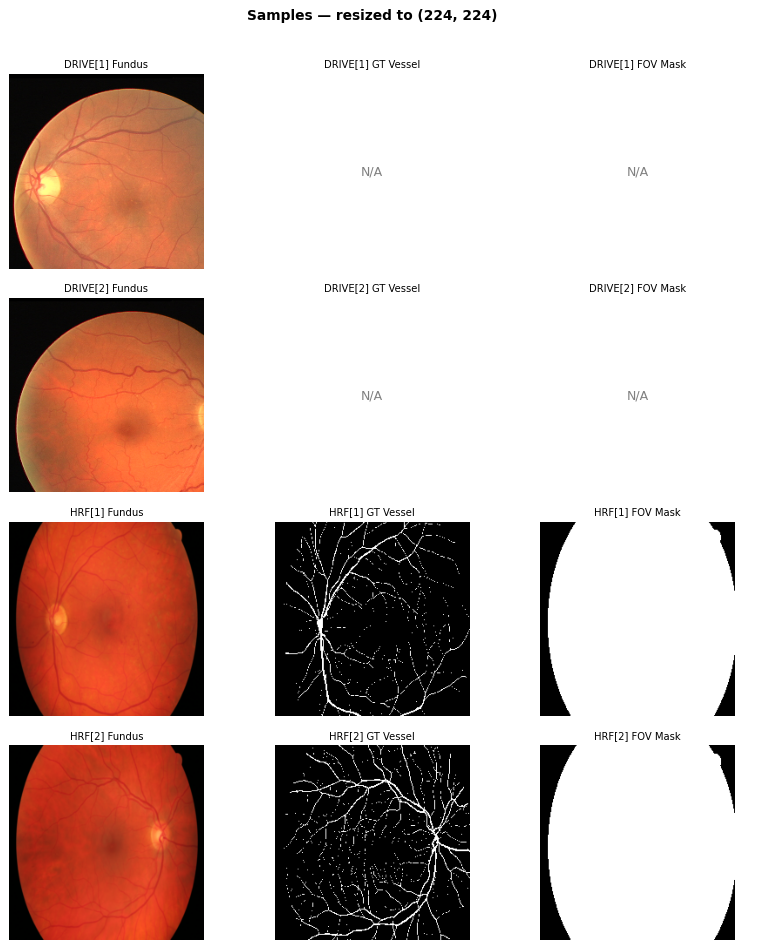

✅ Done


In [ ]:
datasets = [
    ('DRIVE', files['DRIVE_tr_img'], files['DRIVE_tr_gt'],  files['DRIVE_tr_mask']),
    ('HRF',   files['HRF_img'],      files['HRF_gt'],       files['HRF_mask']),
]

total_rows = sum(min(N_SHOW, len(d[1])) for d in datasets)
fig, axes  = plt.subplots(total_rows, 3, figsize=(9, total_rows * 2.6))
if total_rows == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(f'Samples — resized to {THUMB}', fontsize=11,
             fontweight='bold', y=1.01)

row = 0
for ds_name, imgs, gts, masks in datasets:
    for i in range(min(N_SHOW, len(imgs))):
        for ax, fp, mode, cmap, title in zip(
            axes[row],
            [imgs[i], gts[i] if i<len(gts) else None, masks[i] if i<len(masks) else None],
            ['RGB','L','L'],
            [None,'gray','gray'],
            ['Fundus','GT Vessel','FOV Mask']
        ):
            if fp is not None:
                arr = imread_safe(fp, mode)
                ax.imshow(arr, cmap=cmap)
                del arr
            else:
                ax.text(0.5,0.5,'N/A',ha='center',va='center',
                        transform=ax.transAxes, color='gray')
            ax.set_title(f'{ds_name}[{i+1}] {title}', fontsize=8)
            ax.axis('off')
        row += 1

plt.tight_layout()
display(fig)
plt.close(fig)
gc.collect()


## 4. Pixel Statistics (R / G / B)

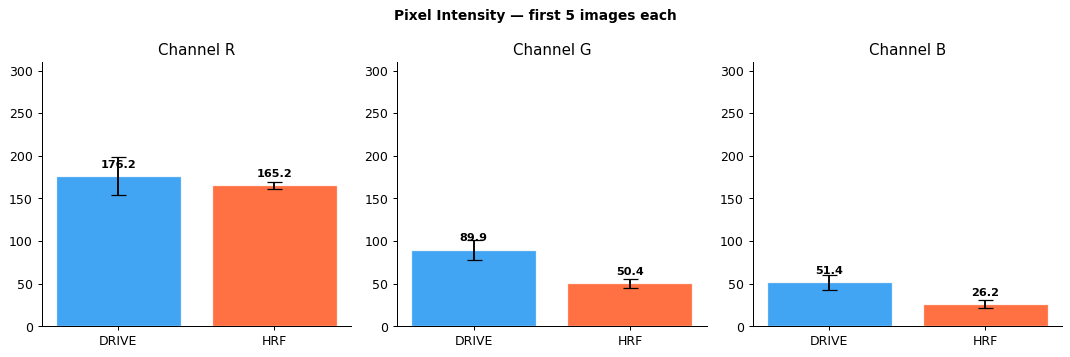

✅ Done


In [5]:
def px_stats(file_list, label, n=N_STATS):
    rows = []
    for f in file_list[:n]:
        img = imread_safe(f, 'RGB').astype(np.float32)
        for c, ch in enumerate(['R','G','B']):
            px = img[..., c]
            rows.append({'dataset':label,'ch':ch,
                         'mean':px.mean(),'std':px.std()})
        del img; gc.collect()
    return pd.DataFrame(rows)

df_px = pd.concat([
    px_stats(files['DRIVE_tr_img'], 'DRIVE'),
    px_stats(files['HRF_img'],      'HRF'),
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f'Pixel Intensity — first {N_STATS} images each',
             fontsize=11, fontweight='bold')
for ax, ch in zip(axes, ['R','G','B']):
    sub  = df_px[df_px.ch==ch].groupby('dataset')['mean']\
                               .agg(['mean','std']).reset_index()
    cols = [COLORS.get(d,'gray') for d in sub['dataset']]
    bars = ax.bar(sub['dataset'], sub['mean'], color=cols, alpha=0.85,
                  yerr=sub['std'], capsize=6, edgecolor='white')
    ax.set_title(f'Channel {ch}'); ax.set_ylim(0, 310)
    for b,v in zip(bars, sub['mean']):
        ax.text(b.get_x()+b.get_width()/2, v+10, f'{v:.1f}',
                ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
display(fig); plt.close(fig); gc.collect()
print('✅ Done')

## 5. Vessel Density (GT masks)

          mean    std    min     max
dataset                             
HRF      9.222  1.709  5.852  12.765


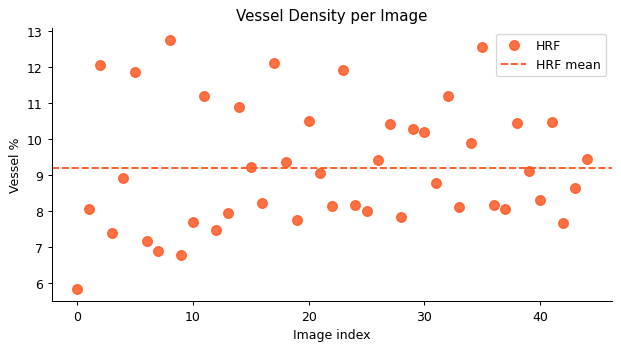

✅ Done


In [ ]:
def vessel_density(gt_list, fov_list, label):
    rows = []
    for i, gt_f in enumerate(gt_list):
        gt_b = imread_safe(gt_f, 'L') > 127
        if i < len(fov_list):
            fov_b = imread_safe(fov_list[i], 'L') > 127
            total   = int(fov_b.sum())
            vessels = int((gt_b & fov_b).sum())
            del fov_b
        else:
            total, vessels = gt_b.size, int(gt_b.sum())
        del gt_b; gc.collect()
        rows.append({'dataset':label,'file':gt_f.name,
                     'pct': vessels/total*100 if total else 0})
    return pd.DataFrame(rows)

df_vd = pd.concat([
    vessel_density(files['DRIVE_tr_gt'], files['DRIVE_tr_mask'], 'DRIVE'),
    vessel_density(files['HRF_gt'],      files['HRF_mask'],      'HRF'),
], ignore_index=True)

print(df_vd.groupby('dataset')['pct']
      .agg(['mean','std','min','max']).round(3))

fig, ax = plt.subplots(figsize=(7, 4))
for ds, grp in df_vd.groupby('dataset'):
    ax.scatter(range(len(grp)), grp['pct'],
               label=ds, color=COLORS[ds], s=60, alpha=0.85)
    ax.axhline(grp['pct'].mean(), color=COLORS[ds],
               linestyle='--', lw=1.5, label=f'{ds} mean')
ax.set_xlabel('Image index'); ax.set_ylabel('Vessel %')
ax.set_title('Vessel Density per Image'); ax.legend()
plt.tight_layout()
display(fig); plt.close(fig); gc.collect()


## 6. Color Histograms (Green channel)

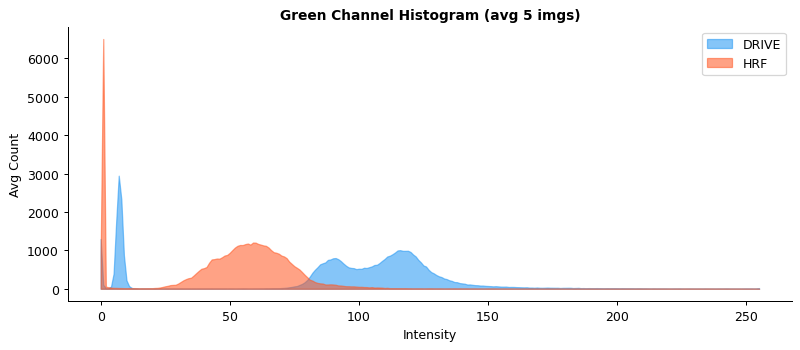

✅ Done


In [7]:
def avg_hist_green(file_list, n=N_STATS):
    h = np.zeros(256)
    for f in file_list[:n]:
        img = imread_safe(f)[..., 1]
        hh, _ = np.histogram(img.ravel(), bins=256, range=(0,256))
        h += hh; del img
    gc.collect()
    return h / min(n, len(file_list))

h_d = avg_hist_green(files['DRIVE_tr_img'])
h_h = avg_hist_green(files['HRF_img'])

x   = np.arange(256)
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(x, h_d, alpha=0.55, color=COLORS['DRIVE'], label='DRIVE')
ax.fill_between(x, h_h, alpha=0.55, color=COLORS['HRF'],   label='HRF')
ax.set_title(f'Green Channel Histogram (avg {N_STATS} imgs)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Intensity'); ax.set_ylabel('Avg Count'); ax.legend()
plt.tight_layout()
display(fig); plt.close(fig); gc.collect()
print('✅ Done')

## 7. Quality Metrics (Brightness / Contrast / Sharpness)

In [ ]:
import cv2

def quality_metrics(file_list, label, n=N_STATS):
    rows = []
    for f in file_list[:n]:
        img  = imread_safe(f)                                     # (224,224,3) uint8
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
        lap  = cv2.Laplacian(gray.astype(np.uint8), cv2.CV_32F)
        rows.append({'dataset': label, 'file': f.name,
                     'brightness': float(gray.mean()),
                     'contrast'  : float(gray.std()),
                     'sharpness' : float(lap.var())})
        del img, gray, lap
    gc.collect()
    return pd.DataFrame(rows)

df_qm = pd.concat([
    quality_metrics(files['DRIVE_tr_img'], 'DRIVE'),
    quality_metrics(files['HRF_img'],      'HRF'),
])

print(df_qm.groupby('dataset')[['brightness','contrast','sharpness']].mean().round(2))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Image Quality Metrics', fontsize=11, fontweight='bold')
for ax, m in zip(axes, ['brightness','contrast','sharpness']):
    data = [df_qm[df_qm.dataset=='DRIVE'][m].values,
            df_qm[df_qm.dataset=='HRF'][m].values]
    bp   = ax.boxplot(data, labels=['DRIVE','HRF'], patch_artist=True,
                      medianprops=dict(color='black',linewidth=2))
    for patch, c in zip(bp['boxes'], [COLORS['DRIVE'], COLORS['HRF']]):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_title(m.capitalize())
plt.tight_layout()
plt.savefig('quality_metrics.png', dpi=90, bbox_inches='tight')
plt.show()
plt.close('all'); gc.collect()

## 8. Normalization Stats (for transforms)

In [8]:
all_train = files['DRIVE_tr_img'] + files['HRF_img']
print(f'Computing over {len(all_train)} images...')

s1 = np.zeros(3); s2 = np.zeros(3); N = 0
for f in all_train:
    img = imread_safe(f).astype(np.float64) / 255.0
    for c in range(3):
        s1[c] += img[...,c].sum()
        s2[c] += (img[...,c]**2).sum()
    N += THUMB[0]*THUMB[1]
    del img
gc.collect()

mean = s1/N
std  = np.sqrt(np.maximum(s2/N - mean**2, 1e-8))
print(f'\n✅ mean = {mean.round(4).tolist()}')
print(f'   std  = {std.round(4).tolist()}')
print(f'\ntransforms.Normalize(mean={mean.round(4).tolist()}, std={std.round(4).tolist()})')

Computing over 65 images...

✅ mean = [0.6129, 0.2364, 0.1281]
   std  = [0.3016, 0.1446, 0.0837]

transforms.Normalize(mean=[0.6129, 0.2364, 0.1281], std=[0.3016, 0.1446, 0.0837])


## 9. Final Summary

In [9]:
print('='*60)
d_sizes = df_dim[df_dim.dataset=='DRIVE_tr'][['w','h']].drop_duplicates().values.tolist()
h_sizes = df_dim[df_dim.dataset=='HRF'][['w','h']].drop_duplicates().values.tolist()
print(f'DRIVE size  : {d_sizes}')
print(f'HRF size    : {h_sizes}')
print(f'Target size : {THUMB}  ← all images resized here')
dv = df_vd[df_vd.dataset=='DRIVE']['pct'].mean()
hv = df_vd[df_vd.dataset=='HRF']['pct'].mean()
print(f'\nVessel density  DRIVE:{dv:.2f}%  HRF:{hv:.2f}%  Δ={abs(dv-hv):.2f}%')
print(f'\nTotal train: {len(files["DRIVE_tr_img"])+len(files["HRF_img"])} '
      f'| DRIVE test: {len(files["DRIVE_te_img"])}')
print('='*60)

DRIVE size  : [[565, 584]]
HRF size    : [[3504, 2336]]
Target size : (224, 224)  ← all images resized here

Vessel density  DRIVE:nan%  HRF:9.22%  Δ=nan%

Total train: 65 | DRIVE test: 20
